In [ ]:
import joblib
import numpy as np
import tensorflow as tf

import matplotlib.pyplot as plt

from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

I0000 00:00:1774538926.569199 2686288 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774538926.576845 2686288 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774538927.173301 2686288 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774538929.249616 2686288 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [6]:
data = np.load('modelling_data.npz')
Xraw = data['Xraw']
yraw = data['yraw']
#yraw_safe = np.clip(data['yraw'], a_min=1e-30, a_max=None)
#yraw = np.log10(yraw_safe)
Xfit = data['Xfit']
yfit = data['yfit']
#yfit_safe = np.clip(data['yfit'], a_min=1e-30, a_max=None)
#yfit = np.log10(yfit_safe)
print(Xraw.shape, yraw.shape, Xfit.shape, yfit.shape)

(2541150, 5) (2541150,) (46919314, 5) (46919314,)


In [7]:
dv1 = 10
v2 = 0

selectedindex = np.where((Xraw[:, 0] == dv1) & (Xraw[:, 1] == v2))
Xraw_selected = Xraw[selectedindex]
yraw_selected = yraw[selectedindex]
print(Xraw_selected.shape, yraw_selected.shape)
j1s_raw = Xraw_selected[:, 2]
j2s_raw = Xraw_selected[:, 3]
es_raw = Xraw_selected[:, 4]
selectedindex = np.where((Xfit[:, 0] == dv1) & (Xfit[:, 1] == v2))
Xfit_selected = Xfit[selectedindex]
yfit_selected = yfit[selectedindex]
print(Xfit_selected.shape, yfit_selected.shape)     
j1s_fit = Xfit_selected[:, 2]
j2s_fit = Xfit_selected[:, 3]
es_fit = Xfit_selected[:, 4]


(27000, 5) (27000,)
(490777, 5) (490777,)


(450, 5) (450,)
(8321, 5) (8321,)


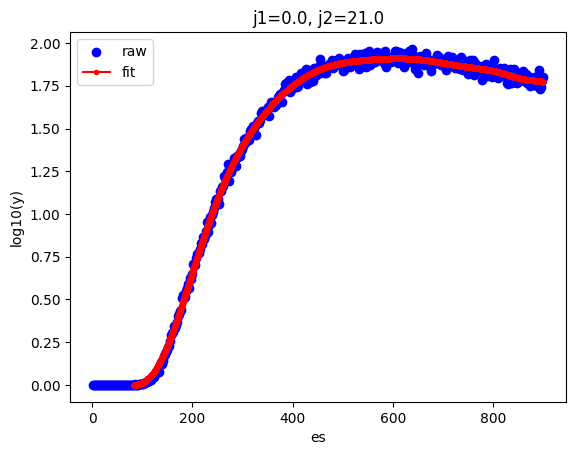

In [15]:
# testplot 
j1 = j1s_raw[0]
j2 = j2s_raw[0]

selectedindex = np.where((Xraw_selected[:, 2] == j1) & (Xraw_selected[:, 3] == j2))
xraw = Xraw_selected[selectedindex]
yraw = yraw_selected[selectedindex]
print(xraw.shape, yraw.shape)
es = xraw[:, 4]

selectedindex = np.where((Xfit_selected[:, 2] == j1) & (Xfit_selected[:, 3] == j2))
xfit = Xfit_selected[selectedindex]
yfit = yfit_selected[selectedindex]
print(xfit.shape, yfit.shape)
esfit = xfit[:, 4]

plt.scatter(es, yraw, marker='o', color='blue', label='raw')  
# plot as a line plot
plt.plot(esfit, yfit, marker='.', color='red', label='fit')
plt.xlabel('es')
plt.ylabel('log10(y)')
plt.title(f'j1={j1}, j2={j2}')
plt.legend()
plt.show()
